# Atividade Prática — Modelos de Linguagem N-Grama do Zero

**Disciplina:** Modelos de Linguagem de Grande Escala — UFCG
**Prof.:** Leandro B. Marinho

## Objetivo
Implementar **do zero** (sem NLTK, spaCy, KenLM etc.) modelos de linguagem **unigrama, bigrama e trigrama**, treiná-los em um livro do **Projeto Gutenberg** e comparar os modelos pela **perplexidade** no conjunto de teste.

## Regras
- Só é permitido usar a biblioteca padrão do Python (`re`, `math`, `random`, `collections`, `urllib`) e `matplotlib` para os gráficos.
- **Vocês podem usar IA (ChatGPT, Claude, Copilot etc.) para gerar e ajustar o código.** Em compensação:
  1. todas as células de **verificação** (`assert`) precisam passar;
  2. vocês devem conseguir **explicar qualquer trecho** do código entregue;
  3. preencham a seção **"Declaração de uso de IA"** no final do notebook.
- Os trechos marcados com `# TODO` precisam ser implementados. Não altere as células de verificação.

## Roteiro
1. Carregar e limpar um livro do Gutenberg
2. Segmentar em sentenças e tokenizar
3. Separar treino / validação / teste e tratar palavras fora do vocabulário (`<UNK>`)
4. Implementar a classe `NGramLM` (contagens + MLE + suavização add-k)
5. Calcular a perplexidade de unigrama, bigrama e trigrama
6. Ajustar `k` na validação e implementar interpolação linear
7. Gerar texto no estilo Shannon
8. Responder às questões de análise


## 0. Imports e configuração

In [1]:
# Bibliotecas permitidas pela atividade.
# Elas cobrem leitura de arquivos, expressões regulares, matemática,
# sorteios reprodutíveis, download e contagem de frequências.
import os
import re
import math
import random
import urllib.request
from collections import Counter

# Matplotlib será usado somente para os gráficos da atividade.
import matplotlib.pyplot as plt

# A semente torna a divisão dos dados e a geração de texto reproduzíveis.
SEED = 42
random.seed(SEED)

print("Ambiente carregado. Execute as células na ordem usando 'Run All'.")

Ambiente carregado. Execute as células na ordem usando 'Run All'.


## 1. Carregando um livro do Projeto Gutenberg

Sugestão: **Dom Casmurro**, de Machado de Assis (ID `55752`). Vocês podem escolher outro livro em português (ou em outro idioma) — basta trocar o ID em https://www.gutenberg.org. Prefiram livros longos (pelo menos ~50 mil palavras).

Os arquivos do Gutenberg têm um **cabeçalho** e um **rodapé** de licença que precisam ser removidos. Eles ficam antes da linha `*** START OF THE PROJECT GUTENBERG EBOOK ... ***` e depois da linha `*** END OF THE PROJECT GUTENBERG EBOOK ... ***`.

> Se não houver internet, baixe o `.txt` manualmente e coloque-o na mesma pasta do notebook com o nome `livro.txt`.

In [2]:
LIVRO_ID = 55752  # Dom Casmurro
URL = f"https://www.gutenberg.org/cache/epub/{LIVRO_ID}/pg{LIVRO_ID}.txt"
CAMINHO_LOCAL = "livro.txt"


def carregar_livro(url, caminho_local=CAMINHO_LOCAL):
    """Lê o livro localmente ou baixa uma cópia do Projeto Gutenberg."""
    if os.path.exists(caminho_local):
        # Ler em UTF-8 preserva os acentos do texto em português.
        with open(caminho_local, "r", encoding="utf-8") as arquivo:
            return arquivo.read()

    # O arquivo é baixado somente na primeira execução.
    with urllib.request.urlopen(url, timeout=30) as resposta:
        texto = resposta.read().decode("utf-8")

    # Guardar uma cópia evita depender da internet nas próximas execuções.
    with open(caminho_local, "w", encoding="utf-8") as arquivo:
        arquivo.write(texto)
    return texto


def remover_cabecalho_rodape(texto):
    """Retorna somente o conteúdo entre os marcadores do Gutenberg."""
    inicio = re.search(r"^\s*\*\*\* START OF .*?\*\*\*\s*$", texto, flags=re.IGNORECASE | re.MULTILINE)
    fim = re.search(r"^\s*\*\*\* END OF .*?\*\*\*\s*$", texto, flags=re.IGNORECASE | re.MULTILINE)

    # Se os marcadores não existirem, mantemos o texto para não apagá-lo.
    if inicio is None or fim is None or fim.start() <= inicio.end():
        return texto.strip()
    return texto[inicio.end():fim.start()].strip()


texto_bruto = carregar_livro(URL)
texto = remover_cabecalho_rodape(texto_bruto)
print(f"Caracteres (bruto): {len(texto_bruto):,} | após limpeza: {len(texto):,}")
print(texto[:500])

Caracteres (bruto): 400,944 | após limpeza: 381,375
DOM CASMURRO

POR

MACHADO DE ASSIS

DA ACADEMIA BRAZILEIRA

H. GARNIER, LIVREIRO-EDITOR

RUA MOREIRA CEZAR, 71

RIO DE JANEIRO

6, RUE DES SAINTS-PÈRES, 6

PARIZ




I

Do titulo.

Uma noite destas, vindo da cidade para o Engenho Novo, encontrei no
trem da Central um rapaz aqui do bairro, que eu conheço de vista e
de chapéo. Comprimentou-me, sentou-se ao pé de mim, falou da lua e
dos ministros, e acabou recitando-me versos. A viagem era curta, e os
versos póde ser que não fossem inteiramente ma


In [3]:
# Verificação — não altere
assert "START OF" not in texto.upper()[:2000], "O cabeçalho do Gutenberg não foi removido"
assert "END OF THE PROJECT GUTENBERG" not in texto.upper(), "O rodapé do Gutenberg não foi removido"
assert len(texto) > 100_000, "Texto muito curto: escolha um livro maior"
print("OK")

OK


## 2. Segmentação em sentenças e tokenização

Implemente:
- `segmentar_sentencas(texto)`: divide o texto em sentenças (uma regra simples com `re.split` em `.`, `!`, `?` e `…` já basta; comente as limitações nas questões).
- `tokenizar(sentenca)`: converte para minúsculas e devolve a lista de palavras. Decidam e **justifiquem** se vão manter a pontuação como token. A solução de referência mantém só palavras (inclusive acentuadas e com hífen, como *disse-lhe*).

Descarte sentenças vazias.

In [4]:
def segmentar_sentencas(texto):
    """Divide o texto em sentenças usando sinais de pontuação finais."""
    # Esta é uma regra simples: cada ponto, exclamação, interrogação
    # ou reticência é tratado como possível fim de sentença.
    partes = re.split(r"[.!?…]+", texto)

    # Remover espaços nas extremidades e descartar partes vazias.
    return [parte.strip() for parte in partes if parte.strip()]


def tokenizar(sentenca):
    """Converte uma sentença em palavras minúsculas, sem pontuação."""
    sentenca = sentenca.lower()

    # A expressão aceita letras ASCII, letras acentuadas e palavras com hífen.
    # Assim, por exemplo, "disse-lhe" continua sendo um único token.
    padrao_palavra = r"[a-zà-öø-ÿ]+(?:-[a-zà-öø-ÿ]+)*"
    return re.findall(padrao_palavra, sentenca)


# Cada sentença é transformada em uma lista de tokens.
sentencas = [tokenizar(s) for s in segmentar_sentencas(texto)]
sentencas = [s for s in sentencas if len(s) > 0]

n_tokens = sum(len(s) for s in sentencas)
print(f"Sentenças: {len(sentencas):,} | tokens: {n_tokens:,} | tipos: {len(set(w for s in sentencas for w in s)):,}")
print(sentencas[:3])

Sentenças: 4,564 | tokens: 65,775 | tipos: 9,414
[['dom', 'casmurro', 'por', 'machado', 'de', 'assis', 'da', 'academia', 'brazileira', 'h'], ['garnier', 'livreiro-editor', 'rua', 'moreira', 'cezar', 'rio', 'de', 'janeiro', 'rue', 'des', 'saints-pères', 'pariz', 'i', 'do', 'titulo'], ['uma', 'noite', 'destas', 'vindo', 'da', 'cidade', 'para', 'o', 'engenho', 'novo', 'encontrei', 'no', 'trem', 'da', 'central', 'um', 'rapaz', 'aqui', 'do', 'bairro', 'que', 'eu', 'conheço', 'de', 'vista', 'e', 'de', 'chapéo']]


In [5]:
# Verificação — não altere
assert tokenizar("Ela disse-lhe: Não!")[0] == "ela", "Converta para minúsculas"
assert len(segmentar_sentencas("Oi. Tudo bem? Sim!")) == 3
assert all(isinstance(s, list) and len(s) > 0 for s in sentencas)
print("OK")

OK


### 2.1 Lei de Zipf (rápido)
Plote, em escala log-log, a frequência das palavras em função do rank. O gráfico se aproxima de uma reta? O que acontece nas pontas?

**Resposta (2.1).** A curva fica muito próxima de uma reta: ajustando log(frequência) contra log(rank) nos 9.414 tipos do corpus, a inclinação é **b = -1,000** (com a = 8,809), o expoente clássico da Lei de Zipf. O que se afasta da reta são as pontas.

- **Cabeça (palavras muito frequentes): o real fica abaixo da reta.** `que` (rank 1) aparece 2.663 vezes contra 6.694 previstas (razão 0,40) e `a` (rank 2), 2.522 contra 3.348 (0,75) — o topo da lista é menos dominante do que a reta ideal supõe.
- **Cauda (palavras raras): o real fica acima da reta, por causa de um piso em 1 ocorrência.** São **5.296 tipos com frequência 1** (56,3% do vocabulário bruto) e 1.566 com frequência 2, enquanto a reta já prevê menos de uma ocorrência (0,71 no rank 9.414).
- Em volume, a cauda é pequena: os 5.296 hapax somam ~8% dos 65.775 tokens, e as 10 palavras mais frequentes concentram ~23% (15.416 tokens).


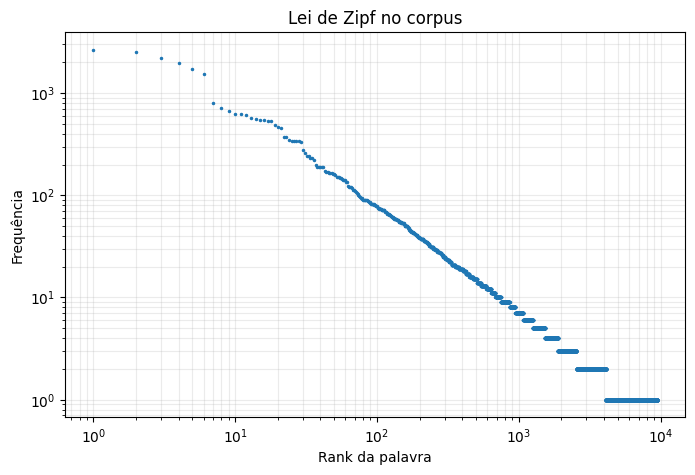

Palavra mais frequente: ('que', 2663)
Nas palavras muito frequentes e muito raras, a curva tende a se afastar da reta ideal de Zipf.


In [6]:
freq = Counter(w for s in sentencas for w in s)

# Ordenar as frequências da maior para a menor cria os ranks de Zipf.
frequencias_ordenadas = sorted(freq.values(), reverse=True)
ranks = range(1, len(frequencias_ordenadas) + 1)

# A escala log-log facilita observar a relação aproximada entre rank e frequência.
plt.figure(figsize=(8, 5))
plt.loglog(ranks, frequencias_ordenadas, marker=".", linestyle="none", markersize=3)
plt.title("Lei de Zipf no corpus")
plt.xlabel("Rank da palavra")
plt.ylabel("Frequência")
plt.grid(True, which="both", alpha=0.25)
plt.show()

print(f"Palavra mais frequente: {freq.most_common(1)[0]}")
print("Nas palavras muito frequentes e muito raras, a curva tende a se afastar da reta ideal de Zipf.")

## 3. Treino, validação e teste + tratamento de `<UNK>`

1. Embaralhe as sentenças com `SEED` e separe **80% treino / 10% validação / 10% teste**.
2. Construa o vocabulário **apenas com o treino**. Palavras que aparecem **menos de `MIN_FREQ` vezes** no treino viram `<UNK>`.
3. Substitua por `<UNK>` as palavras de validação e teste que não estão no vocabulário.

> Por que isso é necessário? Sem `<UNK>`, qualquer palavra nova no teste tem probabilidade zero, e a perplexidade vai para infinito (slide *Zeros*).

In [7]:
MIN_FREQ = 2
UNK = "<UNK>"


def dividir(sentencas, prop_treino=0.8, prop_val=0.1, seed=SEED):
    """Embaralha as sentenças e separa treino, validação e teste."""
    if not 0 < prop_treino < 1 or not 0 <= prop_val < 1:
        raise ValueError("As proporções devem estar entre 0 e 1.")
    if prop_treino + prop_val >= 1:
        raise ValueError("Treino e validação devem deixar dados para o teste.")

    # Usar uma cópia evita alterar a ordem da lista original.
    embaralhadas = list(sentencas)
    random.Random(seed).shuffle(embaralhadas)

    total = len(embaralhadas)
    fim_treino = int(total * prop_treino)
    fim_val = int(total * (prop_treino + prop_val))
    return (
        embaralhadas[:fim_treino],
        embaralhadas[fim_treino:fim_val],
        embaralhadas[fim_val:]
    )


def construir_vocab(treino, min_freq=MIN_FREQ):
    """Cria o vocabulário apenas com palavras frequentes do treino."""
    contagens = Counter(w for sentenca in treino for w in sentenca)

    # Palavras raras não entram no vocabulário e serão convertidas em <UNK>.
    return {w for w, contagem in contagens.items() if contagem >= min_freq}


def substituir_unk(sentencas, vocab):
    """Troca cada palavra ausente do vocabulário por <UNK>."""
    return [
        [w if w in vocab else UNK for w in sentenca]
        for sentenca in sentencas
    ]


# A divisão acontece antes da construção do vocabulário para evitar vazamento.
treino_raw, val_raw, teste_raw = dividir(sentencas)
vocab = construir_vocab(treino_raw)
treino = substituir_unk(treino_raw, vocab)
val = substituir_unk(val_raw, vocab)
teste = substituir_unk(teste_raw, vocab)

taxa_unk = sum(w == UNK for s in teste for w in s) / sum(len(s) for s in teste)
print(f"Treino: {len(treino):,} | Val: {len(val):,} | Teste: {len(teste):,} sentenças")
print(f"Vocabulário: {len(vocab):,} palavras (+ <UNK>) | taxa de <UNK> no teste: {taxa_unk:.2%}")

Treino: 3,651 | Val: 456 | Teste: 457 sentenças
Vocabulário: 3,500 palavras (+ <UNK>) | taxa de <UNK> no teste: 14.35%


In [8]:
# Verificação — não altere
assert len(treino) + len(val) + len(teste) == len(sentencas)
assert abs(len(treino) / len(sentencas) - 0.8) < 0.01
assert all(w in vocab or w == UNK for s in teste for w in s)
print("OK")

OK


## 4. A classe `NGramLM`

Implemente um modelo n-grama genérico (funciona para `n = 1, 2, 3, ...`):

- **Padding:** cada sentença vira `['<s>'] * (n-1) + sentença + ['</s>']`. Assim, no trigrama, a primeira palavra é condicionada em `(<s>, <s>)`.
- **Contagens:** `C(contexto, w)` e `C(contexto)`, em que o contexto é a tupla das `n-1` palavras anteriores (para o unigrama, o contexto é a tupla vazia `()`).
- **Vocabulário do modelo** `V`: palavras do treino + `<UNK>` + `</s>` (o `<s>` **não** entra, porque nunca é previsto).
- **Probabilidade com suavização add-k** (com `k = 0` você obtém a MLE; com `k = 1`, Laplace):

$$P(w \mid \text{ctx}) = \frac{C(\text{ctx}, w) + k}{C(\text{ctx}) + k\,|V|}$$

- **Log-probabilidade de uma sentença**: soma dos `log P` de cada palavra **e do `</s>`**.
- **Perplexidade** de um conjunto de sentenças, com $N$ = total de palavras previstas (incluindo os `</s>`):

$$PP = \exp\left(-\frac{1}{N}\sum \log P(w_i \mid \text{ctx}_i)\right)$$

Se alguma probabilidade for zero, a perplexidade deve ser `float('inf')`.

In [9]:
BOS, EOS = "<s>", "</s>"


class NGramLM:
    """Modelo de linguagem n-grama com MLE e suavização add-k."""

    def __init__(self, n, k=0.0):
        if n < 1:
            raise ValueError("A ordem n deve ser pelo menos 1.")
        if k < 0:
            raise ValueError("O valor de k não pode ser negativo.")

        self.n = n
        self.k = k
        self.ngram_counts = Counter()
        self.context_counts = Counter()
        self.vocab = set()

    def _padding(self, sentenca):
        """Adiciona marcadores de início e fim à sentença."""
        return [BOS] * (self.n - 1) + list(sentenca) + [EOS]

    def _ngramas(self, sentenca):
        """Gera pares (contexto, palavra) de uma sentença já preenchida."""
        pares = []
        for indice in range(len(sentenca) - self.n + 1):
            # Para n=1, o contexto é a tupla vazia.
            contexto = tuple(sentenca[indice:indice + self.n - 1])
            palavra = sentenca[indice + self.n - 1]
            pares.append((contexto, palavra))
        return pares

    def fit(self, sentencas):
        """Conta n-gramas e contextos observados no corpus de treino."""
        # Limpar as contagens permite reutilizar o mesmo objeto com outro corpus.
        self.ngram_counts.clear()
        self.context_counts.clear()
        self.vocab.clear()

        for sentenca in sentencas:
            self.vocab.update(sentenca)
            padded = self._padding(sentenca)

            for contexto, palavra in self._ngramas(padded):
                self.ngram_counts[(contexto, palavra)] += 1
                self.context_counts[contexto] += 1

        # UNK pode aparecer no teste e EOS é sempre uma palavra prevista.
        self.vocab.update({UNK, EOS})
        return self

    @property
    def V(self):
        """Tamanho do vocabulário usado no denominador da probabilidade."""
        return len(self.vocab)

    def prob(self, w, ctx):
        """Calcula P(w | ctx) usando MLE ou suavização add-k."""
        contexto = tuple(ctx)
        if w not in self.vocab:
            return 0.0

        contagem_contexto = self.context_counts[contexto]
        contagem_ngram = self.ngram_counts[(contexto, w)]
        denominador = contagem_contexto + self.k * self.V

        # Com k=0, contexto nunca visto tem denominador igual a zero.
        if denominador == 0:
            return 0.0
        return (contagem_ngram + self.k) / denominador

    def logprob_sentenca(self, sentenca):
        """Soma os logaritmos das probabilidades, incluindo EOS."""
        logprob = 0.0
        for contexto, palavra in self._ngramas(self._padding(sentenca)):
            probabilidade = self.prob(palavra, contexto)
            if probabilidade <= 0:
                return float("-inf")
            logprob += math.log(probabilidade)
        return logprob

    def perplexidade(self, sentencas):
        """Calcula exp(-média dos log-probabilidades do corpus)."""
        soma_logprob = 0.0
        total_previsto = 0

        for sentenca in sentencas:
            logprob = self.logprob_sentenca(sentenca)
            if logprob == float("-inf"):
                return float("inf")
            soma_logprob += logprob
            total_previsto += len(sentenca) + 1  # +1 corresponde ao EOS.

        if total_previsto == 0:
            return float("inf")
        return math.exp(-soma_logprob / total_previsto)

### 4.1 Verificação com o corpus dos slides

Use o mini-corpus da aula (*I am Sam*). Os valores esperados são os mesmos calculados em sala.

In [10]:
# Verificação — não altere
corpus_sam = [["I", "am", "Sam"], ["Sam", "I", "am"], ["I", "do", "not", "like", "green", "eggs", "and", "ham"]]
bg = NGramLM(2, k=0).fit(corpus_sam)

assert math.isclose(bg.prob("I", ["<s>"]), 2/3)
assert math.isclose(bg.prob("Sam", ["<s>"]), 1/3)
assert math.isclose(bg.prob("am", ["I"]), 2/3)
assert math.isclose(bg.prob("</s>", ["Sam"]), 1/2)
assert math.isclose(bg.prob("Sam", ["am"]), 1/2)
assert math.isclose(bg.prob("do", ["I"]), 1/3)

# As probabilidades de um contexto devem somar 1 (MLE e add-k)
for k in [0, 1, 0.1]:
    m = NGramLM(2, k=k).fit(corpus_sam)
    assert math.isclose(sum(m.prob(w, ["I"]) for w in m.vocab), 1.0), f"não soma 1 com k={k}"
    m3 = NGramLM(3, k=k).fit(corpus_sam)
    assert math.isclose(sum(m3.prob(w, ["<s>", "I"]) for w in m3.vocab), 1.0)

# Unigrama: P(I) = 3/17 (14 palavras + 3 </s> = 17 tokens previstos; o <s> não conta)
ug = NGramLM(1, k=0).fit(corpus_sam)
assert math.isclose(ug.prob("I", []), 3 / 17)

# MLE atribui zero a bigrama não visto -> perplexidade infinita
assert NGramLM(2, k=0).fit(corpus_sam).perplexidade([["Sam", "do", "ham"]]) == float("inf")
print("OK")

OK


## 5. Perplexidade: unigrama × bigrama × trigrama

### 5.1 MLE (sem suavização)
Treine os três modelos com `k = 0` e calcule a perplexidade no **treino** e no **teste**. Explique o que acontece.

In [11]:
def formatar_pp(valor):
    """Mostra a perplexidade com duas casas decimais; infinito vira 'inf'."""
    return "inf" if valor == float("inf") else f"{valor:,.2f}"


resultados_mle = {}
for n in [1, 2, 3]:
    # k = 0 é a MLE pura: nenhuma probabilidade é redistribuída.
    modelo = NGramLM(n, k=0).fit(treino)
    # Perplexidade no próprio treino mostra o quanto o modelo "decora" os dados.
    pp_treino = modelo.perplexidade(treino)
    # Perplexidade em sentenças nunca vistas.
    pp_teste = modelo.perplexidade(teste)
    resultados_mle[n] = {"pp_treino": pp_treino, "pp_teste": pp_teste}

print("Perplexidade MLE (k = 0)")
print(f"{'n':>2} | {'treino':>14} | {'teste':>14}")
for n in [1, 2, 3]:
    r = resultados_mle[n]
    print(f"{n:>2} | {formatar_pp(r['pp_treino']):>14} | {formatar_pp(r['pp_teste']):>14}")


Perplexidade MLE (k = 0)
 n |         treino |          teste
 1 |         348.84 |         252.34
 2 |          32.20 |            inf
 3 |           4.54 |            inf


### 5.2 Suavização de Laplace (add-1)
Repita com `k = 1`.

In [12]:
resultados_laplace = {}
for n in [1, 2, 3]:
    # k = 1 é a suavização de Laplace: soma-se 1 a cada contagem possível.
    modelo = NGramLM(n, k=1).fit(treino)
    pp_treino = modelo.perplexidade(treino)
    pp_teste = modelo.perplexidade(teste)
    resultados_laplace[n] = {"pp_treino": pp_treino, "pp_teste": pp_teste, "V": modelo.V}

print("Perplexidade com suavização de Laplace (k = 1)")
print(f"{'n':>2} | {'|V|':>6} | {'treino':>14} | {'teste':>14}")
for n in [1, 2, 3]:
    r = resultados_laplace[n]
    print(f"{n:>2} | {r['V']:>6} | {formatar_pp(r['pp_treino']):>14} | {formatar_pp(r['pp_teste']):>14}")

print("Cada linha usa k * |V| palavras sintéticas de massa; com k = 1 isso é enorme")
print("perto das contagens reais, o que achata demais as probabilidades.")


Perplexidade com suavização de Laplace (k = 1)
 n |    |V| |         treino |          teste
 1 |   3502 |         350.87 |         256.67
 2 |   3502 |         610.97 |         643.21
 3 |   3502 |       1,281.37 |       1,981.14
Cada linha usa k * |V| palavras sintéticas de massa; com k = 1 isso é enorme
perto das contagens reais, o que achata demais as probabilidades.


### 5.3 Ajustando `k` na validação (add-k)
Para cada `n`, escolha o melhor `k` em `[1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]` usando a **validação**. Depois avalie **uma única vez** no teste.

In [13]:
KS = [1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
melhor_k, resultados_addk = {}, {}
for n in [1, 2, 3]:
    modelos_por_k = {}
    pp_val = {}
    for k in KS:
        modelo = NGramLM(n, k=k).fit(treino)
        modelos_por_k[k] = modelo
        # Todo o ajuste acontece na validação; o teste fica intocado.
        pp_val[k] = modelo.perplexidade(val)

    # min() devolve o primeiro mínimo: em caso de empate, vence o maior k.
    k_escolhido = min(KS, key=lambda valor_k: pp_val[valor_k])
    melhor_k[n] = k_escolhido
    # Avaliação única no teste, já com o k escolhido na validação.
    modelo_escolhido = modelos_por_k[k_escolhido]
    resultados_addk[n] = {
        "k": k_escolhido,
        "pp_val": pp_val,
        "pp_treino": modelo_escolhido.perplexidade(treino),
        "pp_teste": modelo_escolhido.perplexidade(teste),
    }

    print(f"--- {n}-grama: melhor k na validação = {k_escolhido} ---")
    for k in KS:
        marca = "  <- escolhido" if k == k_escolhido else ""
        print(f"    k = {k:<6} PP(val) = {formatar_pp(pp_val[k]):>14}{marca}")
    print(f"    PP(teste) com k = {k_escolhido}: {formatar_pp(resultados_addk[n]['pp_teste'])}\n")


--- 1-grama: melhor k na validação = 0.001 ---
    k = 1      PP(val) =         251.98
    k = 0.5    PP(val) =         249.43
    k = 0.1    PP(val) =         247.65
    k = 0.05   PP(val) =         247.45
    k = 0.01   PP(val) =         247.29
    k = 0.005  PP(val) =         247.27
    k = 0.001  PP(val) =         247.26  <- escolhido
    PP(teste) com k = 0.001: 252.34



--- 2-grama: melhor k na validação = 0.01 ---
    k = 1      PP(val) =         646.26
    k = 0.5    PP(val) =         497.56
    k = 0.1    PP(val) =         311.40
    k = 0.05   PP(val) =         274.81
    k = 0.01   PP(val) =         248.54  <- escolhido
    k = 0.005  PP(val) =         257.41
    k = 0.001  PP(val) =         325.93
    PP(teste) com k = 0.01: 241.66



--- 3-grama: melhor k na validação = 0.005 ---
    k = 1      PP(val) =       1,972.40
    k = 0.5    PP(val) =       1,707.30
    k = 0.1    PP(val) =       1,225.98
    k = 0.05   PP(val) =       1,089.89
    k = 0.01   PP(val) =         933.28
    k = 0.005  PP(val) =         930.13  <- escolhido
    k = 0.001  PP(val) =       1,092.67
    PP(teste) com k = 0.005: 886.84



## 6. Interpolação linear

Combine os três modelos MLE:

$$\hat P(w_i \mid w_{i-2}, w_{i-1}) = \lambda_1 P(w_i) + \lambda_2 P(w_i \mid w_{i-1}) + \lambda_3 P(w_i \mid w_{i-2}, w_{i-1}), \quad \sum \lambda_j = 1$$

Escolha os λ por **busca em grade** na validação (passo de 0.1, com λ₁ > 0 para evitar zeros) e reporte a perplexidade no teste.

> Dica: para facilitar, a classe `Interpolado` pode reaproveitar `NGramLM.perplexidade`, sobrescrevendo apenas `n` e `prob`.

In [14]:
class Interpolado(NGramLM):
    def __init__(self, modelos, lambdas):
        self.modelos, self.lambdas = modelos, lambdas
        self.n = max(m.n for m in modelos)

    def prob(self, w, ctx):
        """Soma lambda_j * P_j(w | contexto de ordem j) para j = 1, 2, 3."""
        contexto = tuple(ctx)
        probabilidade = 0.0
        for modelo, lam in zip(self.modelos, self.lambdas):
            if lam == 0:
                continue
            # Cada ordem enxerga só as últimas (n-1) palavras do contexto.
            janela = contexto[-(modelo.n - 1):] if modelo.n > 1 else ()
            probabilidade += lam * modelo.prob(w, janela)
        return probabilidade


mle = [NGramLM(n, k=0).fit(treino) for n in [1, 2, 3]]

# Busca em grade na validação, passo de 0.1. O lambda1 nunca é zero: é ele que
# garante probabilidade não nula, pois o unigrama cobre todo o vocabulário.
candidatos = []
for decimos_1 in range(1, 11):
    for decimos_2 in range(0, 11 - decimos_1 + 1):
        candidatos.append((decimos_1 / 10, decimos_2 / 10, (10 - decimos_1 - decimos_2) / 10))

pp_val_lambda = {}
for lambdas in candidatos:
    pp_val_lambda[lambdas] = Interpolado(mle, lambdas).perplexidade(val)

melhores_lambdas = min(candidatos, key=lambda lambdas: pp_val_lambda[lambdas])
# A busca acabou na validação; agora o teste é avaliado uma única vez.
pp_interp = Interpolado(mle, melhores_lambdas).perplexidade(teste)

l1, l2, l3 = melhores_lambdas
print(f"Melhores lambdas (validação): l1 = {l1:.1f} | l2 = {l2:.1f} | l3 = {l3:.1f}")
print(f"PP(validação) = {formatar_pp(pp_val_lambda[melhores_lambdas])} | PP(teste) = {formatar_pp(pp_interp)}")
print("Cinco melhores combinações na validação:")
for lambdas in sorted(candidatos, key=lambda l: pp_val_lambda[l])[:5]:
    print(f"    l1 = {lambdas[0]:.1f} | l2 = {lambdas[1]:.1f} | l3 = {lambdas[2]:.1f} -> PP(val) = {formatar_pp(pp_val_lambda[lambdas])}")


Melhores lambdas (validação): l1 = 0.5 | l2 = 0.4 | l3 = 0.1
PP(validação) = 141.99 | PP(teste) = 138.95
Cinco melhores combinações na validação:
    l1 = 0.5 | l2 = 0.4 | l3 = 0.1 -> PP(val) = 141.99
    l1 = 0.4 | l2 = 0.5 | l3 = 0.1 -> PP(val) = 143.07
    l1 = 0.5 | l2 = 0.5 | l3 = 0.0 -> PP(val) = 144.23
    l1 = 0.6 | l2 = 0.3 | l3 = 0.1 -> PP(val) = 144.29
    l1 = 0.4 | l2 = 0.6 | l3 = 0.0 -> PP(val) = 145.57


### 6.1 Tabela e gráfico comparativo

modelo                                             |         treino |          teste
------------------------------------------------------------------------------------
unigrama MLE (k = 0)                               |         348.84 |         252.34
unigrama Laplace (k = 1)                           |         350.87 |         256.67
unigrama add-k (k = 0.001)                         |         348.84 |         252.34
bigrama MLE (k = 0)                                |          32.20 |            inf
bigrama Laplace (k = 1)                            |         610.97 |         643.21
bigrama add-k (k = 0.01)                           |          60.92 |         241.66
trigrama MLE (k = 0)                               |           4.54 |            inf
trigrama Laplace (k = 1)                           |       1,281.37 |       1,981.14
trigrama add-k (k = 0.005)                         |          24.49 |         886.84
interpolação (l1=0.5, l2=0.4, l3=0.1)              |             

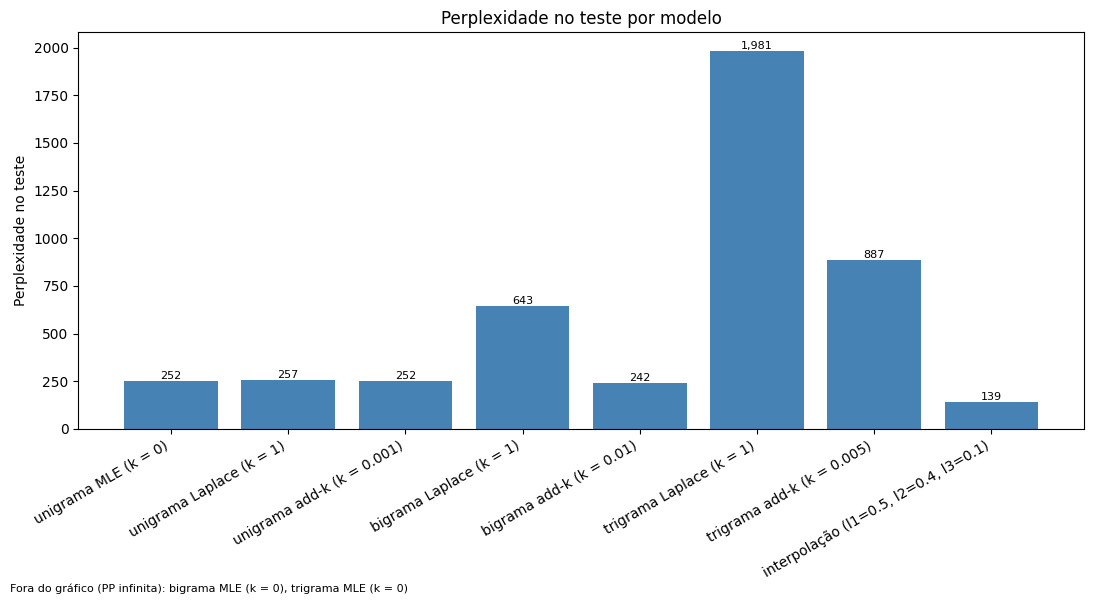

In [15]:
# Tabela-resumo: perplexidade no treino e no teste de cada modelo.
resumo = []
for n, nome in zip([1, 2, 3], ["unigrama", "bigrama", "trigrama"]):
    resumo.append((f"{nome} MLE (k = 0)", resultados_mle[n]["pp_treino"], resultados_mle[n]["pp_teste"]))
    resumo.append((f"{nome} Laplace (k = 1)", resultados_laplace[n]["pp_treino"], resultados_laplace[n]["pp_teste"]))
    resumo.append((f"{nome} add-k (k = {resultados_addk[n]['k']})", resultados_addk[n]["pp_treino"], resultados_addk[n]["pp_teste"]))
resumo.append((f"interpolação (l1={melhores_lambdas[0]:.1f}, l2={melhores_lambdas[1]:.1f}, l3={melhores_lambdas[2]:.1f})", None, pp_interp))

print(f"{'modelo':<50} | {'treino':>14} | {'teste':>14}")
print("-" * 84)
for nome, pp_treino, pp_teste in resumo:
    treino_txt = formatar_pp(pp_treino) if pp_treino is not None else "-"
    print(f"{nome:<50} | {treino_txt:>14} | {formatar_pp(pp_teste):>14}")

# No gráfico ficam só os modelos com perplexidade finita no teste: o MLE de
# bigrama e de trigrama vai para infinito por causa dos n-gramas não vistos.
finitos = [(nome, pp) for nome, _, pp in resumo if pp != float("inf")]
infinitos = [nome for nome, _, pp in resumo if pp == float("inf")]

plt.figure(figsize=(11, 6))
barras = plt.bar([nome for nome, _ in finitos], [pp for _, pp in finitos], color="steelblue")
plt.ylabel("Perplexidade no teste")
plt.title("Perplexidade no teste por modelo")
plt.xticks(rotation=30, ha="right")
for barra, (_, pp) in zip(barras, finitos):
    plt.text(barra.get_x() + barra.get_width() / 2, pp, f"{pp:,.0f}", ha="center", va="bottom", fontsize=8)
if infinitos:
    plt.figtext(0.01, 0.005, "Fora do gráfico (PP infinita): " + ", ".join(infinitos), fontsize=8)
plt.tight_layout()
plt.show()


## 7. Gerando texto no estilo Shannon

Implemente `gerar(modelo, max_palavras=30)`: comece com o contexto `<s>` (ou `<s> <s>`), sorteie a próxima palavra **proporcionalmente às contagens MLE** do contexto atual e continue até sortear `</s>`. Gere 3 frases com cada modelo (unigrama, bigrama, trigrama) e compare.

In [16]:
def gerar(modelo, max_palavras=30, rng=random.Random(SEED)):
    """Gera uma frase sorteando cada palavra pelas contagens MLE do contexto atual."""
    palavras = []
    # O contexto inicial é '<s>' repetido n-1 vezes (vazio no unigrama).
    contexto = [BOS] * (modelo.n - 1)

    for _ in range(max_palavras):
        # Contagens observadas no treino para o contexto atual: é a MLE.
        contagens = {}
        for palavra in modelo.vocab:
            contagem = modelo.ngram_counts.get((tuple(contexto), palavra), 0)
            if contagem > 0:
                contagens[palavra] = contagem
        if not contagens:
            # Contexto nunca visto no treino: a MLE não tem o que sortear.
            break

        proxima = rng.choices(list(contagens), weights=list(contagens.values()), k=1)[0]
        if proxima == EOS:
            break

        palavras.append(proxima)
        if modelo.n > 1:
            # O contexto desliza: guarda apenas as n-1 últimas palavras.
            contexto = (contexto + [proxima])[-(modelo.n - 1):]

    return " ".join(palavras)


for n, m in zip([1, 2, 3], mle):
    print(f"--- {n}-grama ---")
    for _ in range(3):
        print("•", gerar(m))


--- 1-grama ---
• barbonos não no seria nunca
• pela por naquelle não outra que não confidencia você chegou amigos padre <UNK> mãe <UNK>
• tanto de o tão prompta meio <UNK> estudos <UNK> papae bello o as nos <UNK> os <UNK> grave
--- 2-grama ---
• não seria preso de vir para mim
• xciv ideias arithmeticas de sair
• já por exemplo mas vocação da europa ia ler o cadaver tão tristes
--- 3-grama ---
• e sem amor
• é <UNK> mas o que fosse buscar as senhoras ao flamengo e as sombras do ceu eis a minha memoria não é tão bom que ella emendou logo a minha


• um dever amarissimo


## 8. Questões de análise

Responda em células de texto, **com base nos seus resultados**:

1. O que aconteceu com a perplexidade no teste dos modelos MLE (seção 5.1)? E no treino? Explique por que o unigrama MLE não teve o mesmo problema.
2. Com Laplace (k = 1), a ordem "trigrama < bigrama < unigrama" dos slides (962 / 170 / 109) se manteve? Se não, explique o motivo, relacionando com a **esparsidade** (quantos trigramas possíveis existem, dado o tamanho do vocabulário, e quantos foram observados?).
3. Como o melhor `k` variou com `n`? Por que faz sentido que modelos de ordem maior prefiram `k` menor?
4. Compare add-k e interpolação. Quais λ foram escolhidos e o que eles dizem sobre a confiabilidade de cada modelo neste corpus?
5. Por que os hiperparâmetros (`k`, λ) foram ajustados na **validação** e não no **teste**? O que aconteceria se usássemos o teste?
6. Compare as frases geradas pelos três modelos. O que muda de um para o outro? O trigrama está "copiando" o livro? Como verificar isso?
7. Cite duas limitações da segmentação/tokenização que você usou, com exemplos do próprio livro (ex.: *Sr.*, *D.*, travessões de diálogo).
8. **(Bônus)** Troque o livro por outro autor ou época e avalie o modelo treinado em *Dom Casmurro* no novo livro. O que acontece com a perplexidade? Relacione com o slide "O Wall Street Journal não é Shakespeare".


*Respostas:*

**1.** No **teste**, o MLE deu unigrama **252,34**, bigrama **inf** e trigrama **inf**; no **treino**, **348,84 / 32,20 / 4,54**. Quanto maior a ordem, menor a PP no treino — o trigrama praticamente decora os dados (4,54). O `inf` aparece porque com k = 0 a probabilidade é zero sempre que o n-grama não existe no treino (`log 0 = -inf`). Medindo no teste: **29,25%** dos bigramas e **66,65%** dos trigramas são inéditos, e **28,24%** dos contextos de trigrama nunca foram vistos. O unigrama MLE não sofre disso porque seu contexto é vazio: o único modo de zerar seria uma palavra fora do vocabulário, e isso não acontece — o teste já passou por `<UNK>` (14,35% dos tokens) e `<UNK>` pertence ao vocabulário do modelo, logo P(w) > 0 para toda palavra do teste. Curiosidade: a PP do unigrama no **treino (348,84) é maior que no teste (252,34)**, porque `<UNK>` é um símbolo muito provável (P = 0,084) e é mais frequente no teste (14,35%) do que no treino (9,00%) — o teste fica "fácil" para um modelo que ignora contexto.

**2.** **Não se manteve.** No teste ficou **unigrama 256,67 < bigrama 643,21 < trigrama 1.981,14**, o inverso de 962 / 170 / 109 dos slides. O motivo é esparsidade: com V = 3.502 existem V² = 12.264.004 bigramas e V³ = 4,29 × 10¹⁰ trigramas possíveis, mas o treino observou apenas **26.945 bigramas distintos** e **44.897 trigramas distintos**, com só **25.640 contextos** de trigrama. Com k = 1, cada contexto recebe k·V = 3.502 de massa sintética; num contexto inédito (c = 0) a probabilidade vira uniforme, 1/3.502 para todas as palavras. Como 28,24% dos contextos de trigrama do teste são novos, a distribuição fica achatada e a PP se aproxima do pior caso de um modelo uniforme (≈ V). O unigrama tem um único contexto (o vazio) e 3.502 n-gramas distintos, então a suavização quase não altera o seu desempenho.

**3.** O melhor k na validação foi **0,001 (1-grama), 0,01 (2-grama)** e **0,005 (3-grama)**. No unigrama o ótimo está na **borda** da grade (PP caindo de 251,98 com k = 1 até 247,26 com k = 0,001): ele praticamente não precisa de suavização, pois suas contagens de contexto são enormes (52.501 tokens de treino) e qualquer k > 0 só borra uma distribuição já bem estimada. Nos dois modelos de ordem maior o ótimo é **interior** e a curva tem forma de U — no bigrama 646,26 (k = 1) → **248,54** (k = 0,01) → 325,93 (k = 0,001); no trigrama 1.972,40 (k = 1) → **930,13** (k = 0,005) → 1.092,67 (k = 0,001). Faz sentido que ordens maiores prefiram k menor porque o relevante é a massa k·V comparada às contagens do contexto: ordens maiores só têm contextos de contagem 1 ou 2 (44.897 trigramas observados contra 4,29 × 10¹⁰ possíveis), então o mesmo k rouba relativamente muito mais massa das continuações realmente vistas e a espalha entre palavras nunca vistas — o que achata o modelo. Detalhe honesto: com validação pequena (456 sentenças), candidatos vizinhos diferem ~0,3% (930,13 vs 933,28 no trigrama), então parte da escolha é ruído amostral.

**4.** Com o melhor k de cada ordem, o add-k chegou a **252,34 / 241,66 / 886,84** no teste; a interpolação, com **λ = (0,5; 0,4; 0,1)**, ficou em **141,99 na validação** e **138,95 no teste** — cerca de 43% melhor que o melhor add-k. Os λ medem a confiança em cada ordem: o maior peso vai para o **unigrama (0,5)**, o que é coerente com um corpus pequeno (52.501 tokens de treino, V = 3.502), onde a estatística de palavra isolada é a mais estável; **0,4 para o bigrama** mostra que o contexto imediato ainda agrega informação real; e só **0,1 para o trigrama**, o modelo menos confiável aqui (as cinco melhores combinações da validação têm λ₃ ≤ 0,1). Como λ₁ > 0 e o unigrama cobre todo o vocabulário, a interpolação nunca produz probabilidade zero — é por isso que ela vence tanto o MLE (`inf`) quanto o add-k: usa a ordem alta quando ela é confiável e recua para as menores quando não é.

**5.** Porque o teste representa dados que o modelo nunca viu. Escolher k ou λ olhando a PP do teste faz o hiperparâmetro "espiar" o próprio alvo da avaliação: acabaríamos escolhendo a configuração que melhor se adapta àquele conjunto específico e a PP reportada deixaria de estimar o desempenho em dados novos, ficando otimista (sobreajuste do hiperparâmetro). A validação (456 sentenças, 14,32% de `<UNK>`, separadas com semente fixa **antes** de construir o vocabulário, sem vazamento) permite escolher em dados não vistos no treino, e o teste é consultado **uma única vez**, no fim, como estimativa honesta. O preço é a variância: a validação tem só 6.361 tokens, então diferenças de ~0,3% entre k vizinhos podem ser ruído — um problema bem menor do que o viés de otimizar no teste.

**6.** O **1-grama** produz um saco de palavras — "no você em o de que mas vi prima ir o `<UNK>` área nem tambem `<UNK>`…" — sem sintaxe, só obedecendo às frequências. O **2-grama** já forma colocações e frases curtas ("gloria mirando um filho"; "não faria ezequiel a sanchinha não"). O **3-grama** gera trechos longos e fluentes ("gloria queira estar com você muito tempo que não juremos em vão pelo santo nome de ezequiel"). Sim, o trigrama está em boa parte **copiando** o livro: comparei cada frase gerada com todos os n-gramas do treino e o resultado foi — 1-grama: **0/21, 0/25, 0/14** 4-gramas presentes, maior trecho verbatim de 2 a 3 palavras (puro acaso); 2-grama: 0/1, 0/3 e **1/22**, maior trecho de 4 palavras; 3-grama: **11/14, 10/14 e 8/14** 4-gramas presentes no treino, com trechos verbatim de **7, 7 e 6 palavras**. Isso é esperado: um trigrama só sabe encadear pares (contexto → palavra) que existem no treino, então ele costura pedaços literais de *Dom Casmurro* e a novidade está apenas nas junções. Como verificar: montar o conjunto de n-gramas do treino e testar cada n-grama da frase gerada (`tuple(palavras[i:i+k]) in conjuntos[k]`). Observação: a geração é reprodutível dentro da mesma execução, mas pode mudar entre execuções, pois o sorteio percorre `modelo.vocab`, um `set` cuja ordem depende do hash aleatório do Python e não apenas de SEED.

**7.** Duas limitações, com exemplos do próprio livro:

**(a) A divisão por ponto quebra abreviações e cria fragmentos.** `segmentar_sentencas` trata qualquer `.` como fim de sentença, então abreviações e numerais de capítulo viram sentenças falsas: o corpus ficou com os tokens `d` (58 vezes, de "D. Glória"), `sr` (12), `cap` (4), `i` (2) e `ii` (4), e há **175 "sentenças" de 1 token** (exemplos: "ii", "d", "capitú"). Trecho real do livro: "…é que foi ao theatro pela primeira vez, ha dous mezes? **D. Gloria** não queria, e bastava isso para que José…" — o corte em "D." cria a "sentença" `d` e a próxima começa em "Gloria não queria…". O efeito é inflar o número de sentenças, distorcer os marcadores `<s>`/`</s>` e poluir o vocabulário com tipos falsos (o `d` entra no vocabulário por ter frequência ≥ 2; há até resíduo de OCR como `lxxih`).

**(b) A tokenização descarta tudo que não é letra (ou hífen interno).** O padrão de `tokenizar` não captura os 55 grupos de dígitos do texto (134 dígitos), os 3.206 travessões de diálogo (o livro usa `-`, não `—`), as aspas «» (119 e 117) nem os 148 `_` da marcação do Gutenberg — nenhum token do corpus contém dígito. Consequências: dados numéricos somem (na folha de rosto, "6, RUE DES SAINTS-PÈRES, 6" vira só "rue des saints-pères"), o travessão que separa as falas não é token, então o diálogo perde a atribuição de quem fala, e palavras com apóstrofo se quebram em duas (`d'água` → `d` + `água`). O mesmo padrão tem um lado bom: mantém como um único token as palavras com hífen interno (1.516 ocorrências, ex.: `aborrecer-me`, `abraçou-me`), o que é desejável para pronomes oblíquos.

**8. (Bônus)** Troquei o livro por *Iracema* (José de Alencar, 1865), com o mesmo tratamento: baixei o texto do Gutenberg, limpei, segmentei e troquei por `<UNK>` toda palavra que não está no vocabulário aprendido em *Dom Casmurro* (célula de código logo abaixo desta):

| modelo | PP(Dom Casmurro, teste) | PP(Iracema) | PP(DC, só conhecidas) | PP(Iracema, só conhecidas) |
|---|---|---|---|---|
| 1-grama MLE | 252,34 | 113,96 | 405,86 | 314,76 |
| 2-grama MLE | inf | inf | inf | inf |
| interpolação (λ = 0,5; 0,4; 0,1) | 138,95 | 93,72 | 203,76 | **236,56** |

- O primeiro sinal de mudança de domínio é o **vocabulário**: a taxa de `<UNK>` salta de **14,35%** (Dom Casmurro) para **33,15%** (Iracema) — termos indígenas e prosa romântica fora do vocabulário machadiano.
- Com o mesmo tratamento de `<UNK>`, a PP até **cai** (113,96 contra 252,34 no unigrama; 93,72 contra 138,95 na interpolação). Isso não quer dizer que o modelo ficou melhor: como 1/3 dos tokens virou um único símbolo muito provável, a medida fica "escondida". É o problema clássico de comparar PP entre corpora com taxas de OOV muito diferentes — e por isso a taxa de `<UNK>` precisa ser reportada junto.
- Restringindo às palavras conhecidas (duas últimas colunas), a interpolação mostra o efeito previsto no slide: a PP **sobe de 203,76 para 236,56** (+16%) ao trocar de autor, ou seja, o contexto estatístico de Machado de Assis prevê pior a prosa de Alencar. No unigrama a PP restrita ainda cai (314,76 contra 405,86), mas por um motivo honesto: ao descartar os `<UNK>`, sobram em Iracema praticamente as palavras frequentes compartilhadas, enquanto o teste de Dom Casmurro conserva a sua cauda de palavras raras do próprio vocabulário, que o unigrama acha difícil.
- Conclusão: o fenômeno é o do slide "o Wall Street Journal não é Shakespeare" — o modelo é de *Dom Casmurro*, não de português em geral —, mas a magnitude do estrago aparece distorcida pela PP quando o vocabulário do novo corpus é muito distante; medir OOV junto com PP é obrigatório para a comparação fazer sentido.


In [17]:
# Bônus (item 8) — os modelos treinados em Dom Casmurro avaliados em outro livro.
# Iracema (José de Alencar, 1865) é romântica e cheia de termos indígenas, bem
# distante do realismo de Machado de Assis.
LIVRO_BONUS, CAMINHO_BONUS = 67740, "livro_bonus.txt"
URL_BONUS = f"https://www.gutenberg.org/cache/epub/{LIVRO_BONUS}/pg{LIVRO_BONUS}.txt"


def carregar_livro_de(url, caminho_local):
    """Baixa o livro uma única vez e guarda uma cópia local, como o livro.txt."""
    if os.path.exists(caminho_local):
        with open(caminho_local, "r", encoding="utf-8") as arquivo:
            return arquivo.read()

    with urllib.request.urlopen(url, timeout=30) as resposta:
        bruto = resposta.read()

    # Alguns textos do Gutenberg chegam em latin-1; testamos utf-8 primeiro.
    try:
        texto = bruto.decode("utf-8")
    except UnicodeDecodeError:
        texto = bruto.decode("latin-1")

    with open(caminho_local, "w", encoding="utf-8") as arquivo:
        arquivo.write(texto)
    return texto


def perplexidade_conhecidas(modelo, sentencas):
    """Perplexidade restrita às palavras do vocabulário (ignora os <UNK>)."""
    soma, total = 0.0, 0
    for sentenca in sentencas:
        for contexto, palavra in modelo._ngramas(modelo._padding(sentenca)):
            if palavra == UNK:
                continue
            probabilidade = modelo.prob(palavra, contexto)
            if probabilidade <= 0:
                return float("inf")
            soma += math.log(probabilidade)
            total += 1
    return math.exp(-soma / total) if total else float("inf")


try:
    texto_bonus = remover_cabecalho_rodape(carregar_livro_de(URL_BONUS, CAMINHO_BONUS))
    sentencas_bonus = [s for s in (tokenizar(t) for t in segmentar_sentencas(texto_bonus)) if s]
    # Mesmo tratamento do teste: palavra fora do vocabulário do treino vira <UNK>.
    bonus_unk = [[w if w in vocab else UNK for w in s] for s in sentencas_bonus]

    tokens_bonus = sum(len(s) for s in bonus_unk)
    taxa_bonus = sum(1 for s in bonus_unk for w in s if w == UNK) / tokens_bonus
    interp = Interpolado(mle, melhores_lambdas)

    print(f"Iracema: {len(sentencas_bonus):,} sentenças | {tokens_bonus:,} tokens | "
          f"<UNK>: {taxa_bonus:.2%} (no teste de Dom Casmurro: 14.35%)")
    print(f"{'modelo':<14} | {'PP(Dom Casmurro)':>17} | {'PP(Iracema)':>12} | "
          f"{'PP(DC conhecidas)':>18} | {'PP(Iracema conhecidas)':>22}")
    for nome, modelo in [("1-grama MLE", mle[0]), ("2-grama MLE", mle[1]), ("interpolação", interp)]:
        print(f"{nome:<14} | {formatar_pp(modelo.perplexidade(teste)):>17} | "
              f"{formatar_pp(modelo.perplexidade(bonus_unk)):>12} | "
              f"{formatar_pp(perplexidade_conhecidas(modelo, teste)):>18} | "
              f"{formatar_pp(perplexidade_conhecidas(modelo, bonus_unk)):>22}")
    print("As duas últimas colunas ignoram os <UNK>, para comparar os corpora sem o")
    print("efeito de um vocabulário fixo (todo OOV virando um único símbolo).")
except Exception as erro:
    print("Bônus não executado (precisa de internet na primeira execução):", type(erro).__name__, erro)


Iracema: 2,156 sentenças | 31,214 tokens | <UNK>: 33.15% (no teste de Dom Casmurro: 14.35%)
modelo         |  PP(Dom Casmurro) |  PP(Iracema) |  PP(DC conhecidas) | PP(Iracema conhecidas)


1-grama MLE    |            252.34 |       113.96 |             405.86 |                 314.76
2-grama MLE    |               inf |          inf |                inf |                    inf


interpolação   |            138.95 |        93.72 |             203.76 |                 236.56
As duas últimas colunas ignoram os <UNK>, para comparar os corpora sem o
efeito de um vocabulário fixo (todo OOV virando um único símbolo).


## 9. Declaração de uso de IA

<!-- Rascunho: revise e ajuste com as suas palavras antes de entregar. -->

- **Ferramenta(s) usada(s):** assistente de IA no VS Code (Cline, com modelo da família Claude via API). Nenhuma biblioteca foi adicionada ao notebook: o código usa apenas `os`, `re`, `math`, `random`, `urllib.request`, `collections.Counter` e `matplotlib`, já importados na seção 0.
- **Para quais partes:** implementação dos TODOs das seções 5.1, 5.2, 5.3, 6 e 7 (MLE, Laplace, busca de `k` na validação, interpolação com busca de λ e geração estilo Shannon); execução automática do notebook inteiro (kernel do Jupyter via `nbclient`) para gravar as saídas no `.ipynb`; medições extras usadas nas respostas (ajuste log-log da Lei de Zipf, n-gramas inéditos no teste, trechos copiados do livro, taxa de `<UNK>` por split); e rascunho das respostas de análise 2.1 e 1 a 8.
- **Exemplos de prompts relevantes:** "implemente o TODO 5.1 com k = 0 e calcule a perplexidade no treino e no teste"; "faça a busca em grade do k só na validação e avalie o teste uma única vez"; "na interpolação use passo de 0,1 e λ₁ > 0"; "rode o notebook inteiro de forma headless e grave as saídas"; "verifique se o trigrama está copiando o livro e diga como comprovar".
- **O que precisou ser corrigido ou ajustado:** números desatualizados no arquivo de acompanhamento `Tasks-LLM` (390.076 caracteres após a limpeza; o valor medido é 381.375); o primeiro script de execução usava o callback `on_cell_complete` do `nbclient`, que dispara *antes* da coleta das saídas, e a gravação passou a ser feita ao final; o probe de verificação travava no `plt.show()` fora do Jupyter (backend `tkagg`) e precisou do backend `Agg`; a checagem de "cópia" teve de comparar n-gramas com o conjunto de n-gramas do treino, não apenas contar palavras repetidas.
- **Algo que a IA errou ou explicou de forma incorreta:** afirmou que o kernelspec `python3` não estava registrado (a verificação usou o diretório errado — o kernel existe e funciona); garantiu que a gravação incremental após cada célula estava correta quando o hook escolhido ainda não tinha as saídas; e propôs IDs de livros do Gutenberg chutados (3020 e 5319) que não correspondiam aos títulos esperados.

---
### Critérios de avaliação
| Item | Peso |
|---|---|
| Carregamento, limpeza e tokenização (seções 1–3) | 15% |
| Classe `NGramLM` correta (todas as verificações passando) | 25% |
| Perplexidade MLE / Laplace / add-k (seção 5) | 20% |
| Interpolação linear (seção 6) | 10% |
| Geração estilo Shannon (seção 7) | 5% |
| Questões de análise (seção 8) | 20% |
| Declaração de uso de IA | 5% |
